<a href="https://colab.research.google.com/github/namirachmi08/Feature-Engineering/blob/main/Kelompok_Pemteks_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kelas 2025C

Nama Anggota Kelompok:

Namira Rachmi Andini (Nim 25031554153)

Syahira Nanda Raihanna (Nim 25031554199)

# Chapter 5 - Feature Engineering

## 1. One Hot Encoding

Setiap kata dibuat menjadi fitur 0 atau 1

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

words = df["Text_Clean"].apply(lambda x: x.split())

mlb = MultiLabelBinarizer()
one_hot = mlb.fit_transform(words)

df_onehot = pd.DataFrame(one_hot, columns=mlb.classes_)
df_onehot.head()

,aaron,abandon,abbi,abbot,abduct,abid,abigail,abil,abl,abound,...,zen,zero,zeu,zimbardo,zodiac,zoey,zombi,zone,zorin,zuko
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Bag of Words

BoW menghitung berapa kali setiap kata muncul dalam setiap dokumen.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

bow = vectorizer.fit_transform(df["Text_Clean"])

df_bow = pd.DataFrame(bow.toarray(),columns=vectorizer.get_feature_names_out())
df_bow.head()

,aaron,abandon,abbi,abbot,abduct,abid,abigail,abil,abl,abound,...,zen,zero,zeu,zimbardo,zodiac,zoey,zombi,zone,zorin,zuko
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. TF-IDF

TF-IDF memberikan bobot pada kata berdasarkan seberapa penting kata tersebut dalam suatu dokumen dibandingkan seluruh dokumen.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

tfidf = tfidf_vectorizer.fit_transform(df["Text_Clean"])

df_tfidf = pd.DataFrame(
    tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

df_tfidf.head()

,aaron,abandon,abbi,abbot,abduct,abid,abigail,abil,abl,abound,...,zen,zero,zeu,zimbardo,zodiac,zoey,zombi,zone,zorin,zuko
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.062538,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Word2Vec

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 33.6 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

# Tokenisasi
sentences = df["Text_Clean"].apply(lambda x: x.split()).tolist()

# Word2Vec
model_w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

# Melihat vektor salah satu kata
word = sentences[0][0]

print("Kata:", word)
print("Vektor:", model_w2v.wv[word])

Kata: light
Vektor: [-0.18801348  0.3573657   0.27700457 -0.08154976 -0.03380954 -0.7212036
  0.11507089  0.8641104  -0.32226378 -0.14244513 -0.16985394 -0.52333987
 -0.09897299 -0.00457697  0.09795388 -0.34387237 -0.02908522 -0.39546221
 -0.02299053 -0.68635523  0.33480108  0.26221693  0.21641123 -0.22828671
 -0.02695457  0.1640371  -0.06238648 -0.22572908 -0.32539356 -0.11211664
  0.5417588  -0.0138627  -0.09428731 -0.31231597 -0.11638917  0.39999148
 -0.02494158 -0.15401289 -0.20287348 -0.82087505  0.03435306 -0.29585928
 -0.1573468  -0.00210511  0.46799463 -0.23823382 -0.5079571   0.06481067
  0.15114409  0.21998884  0.04486459 -0.31906196 -0.17047918 -0.13738698
 -0.41766378  0.4402506   0.35696185 -0.19189207 -0.38134104  0.04541987
  0.20494178  0.16978325 -0.1268317   0.15416043 -0.3430545   0.39872557
  0.0560191   0.26265836 -0.4177685   0.43911767 -0.23813279  0.28994724
  0.4611401  -0.11128235  0.34771657  0.22576857  0.00814611 -0.01217103
 -0.40007123  0.05423319 -0.2624

In [ ]:
# Untuk mendapatkan fitur berupa satu vektor untuk setiap buku:
import numpy as np

def document_vector(model, words):
    vectors = [model.wv[word] for word in words if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

w2v_features = np.array([
    document_vector(model_w2v, words)
    for words in sentences
])

print("Ukuran fitur Word2Vec:", w2v_features.shape)

Ukuran fitur Word2Vec: (1000, 100)


## FastText

In [ ]:
from gensim.models import FastText

# FastText
model_ft = FastText(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

word = sentences[0][0]

print("Kata:", word)
print("Vektor:", model_ft.wv[word])

Kata: light
Vektor: [-0.2630688  -0.06849469 -0.04691506  0.06521034  0.32976976  0.5908012
  0.333929   -0.27270696  0.49797115 -0.79724014  0.334016   -0.30462497
 -0.38106537  0.95505154 -0.21091843  0.03576523 -0.26874676 -0.08100934
 -0.7160032  -0.40343907 -0.67453283  0.16735572 -0.7281314  -0.5921682
  0.17110017  0.08509005 -0.17272553 -0.20829299  0.5282571  -0.0827373
 -0.51250374 -0.42907104  0.85361    -0.3107005  -0.6161001  -0.26928166
 -0.27148542  0.64938533 -0.39678732  0.11625829  0.5812285  -1.0410393
  0.21227711 -0.27028665 -1.4023993  -0.28891486 -0.0027699  -0.88669896
  0.20520388  0.6979798  -0.30070263 -0.44401208  0.34111995 -0.3340779
 -0.33583182 -0.17890257  0.05716122  0.32597452 -0.2300505  -0.17195192
  0.6543814  -0.52181417 -0.6988637   0.37018734  0.2175496   1.2645501
  0.4248688   0.30141836  0.33861604  0.71295583  0.57134336  0.22365901
 -0.16101025 -0.4077626   1.1162106  -0.05957412  0.9837157   0.08049273
 -0.4384493   0.7478863  -0.37576535 

In [ ]:
# Fitur setiap buku
fasttext_features = np.array([
    document_vector(model_ft, words)
    for words in sentences
])

print("Ukuran fitur FastText:", fasttext_features.shape)

Ukuran fitur FastText: (1000, 100)


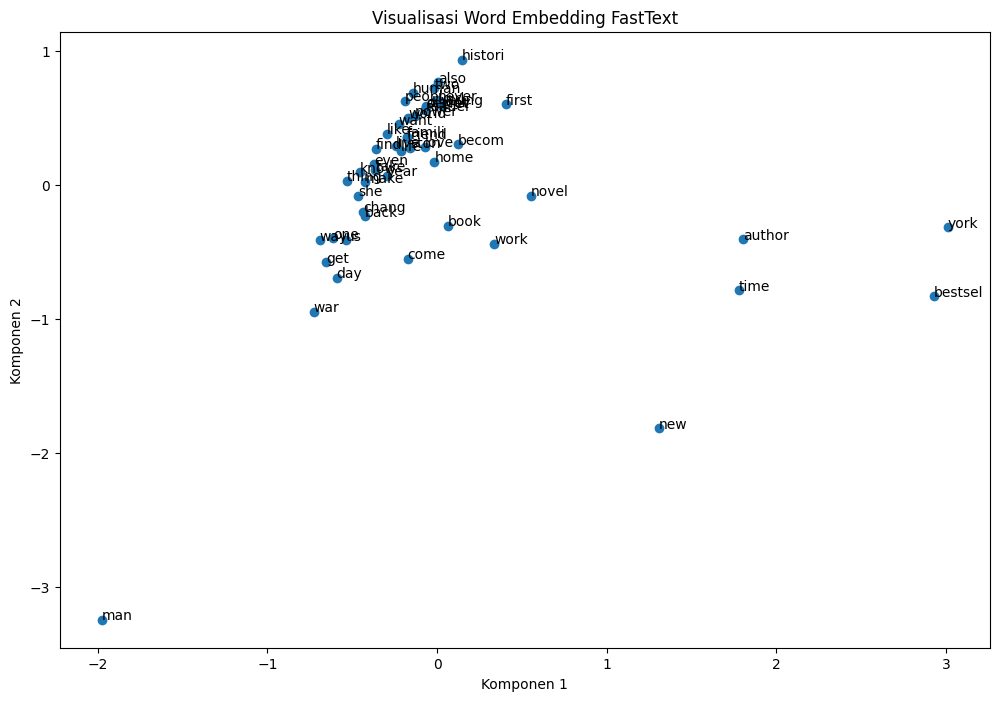

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Ambil beberapa kata dari vocabulary FastText
words = list(model_ft.wv.key_to_index.keys())[:50]

# Ambil vektor kata
vectors = [model_ft.wv[word] for word in words]

# Reduksi dimensi dari 100 menjadi 2
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Visualisasi
plt.figure(figsize=(12, 8))

plt.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1]
)

for i, word in enumerate(words):
    plt.annotate(
        word,
        (vectors_2d[i, 0], vectors_2d[i, 1])
    )

plt.title("Visualisasi Word Embedding FastText")
plt.xlabel("Komponen 1")
plt.ylabel("Komponen 2")
plt.show()

## 6. GloVe



In [ ]:
import gensim.downloader as api

glove_model = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded
Jumlah vocabulary: 400000
Ukuran vector: 100


In [ ]:
print("Vocabulary:", len(glove_model.key_to_index))
print("Vector size:", glove_model.vector_size)

In [ ]:
word = "book"
vector = glove_model[word]

print(vector)

[-1.9744e-01  4.4831e-01  1.3689e-01 -1.5595e-01  9.3600e-01  7.2986e-01
  3.4099e-01 -3.3896e-01 -8.9569e-02 -4.7706e-01  3.5112e-01 -4.2198e-01
 -1.2221e-01 -6.3375e-02 -4.5820e-01  7.8723e-01  9.4045e-01  8.1101e-02
 -2.3224e-01  4.0778e-01  3.3258e-01 -4.4458e-01 -4.7117e-01  1.4852e-01
  9.6308e-01 -6.5267e-02 -5.3661e-02 -6.7474e-01 -4.2364e-01  9.4392e-02
 -3.8668e-01  1.8237e-01 -1.2846e-01 -2.1952e-01 -5.8993e-01  7.3602e-01
 -2.4009e-01  3.2392e-01 -2.4663e-01 -4.0684e-01 -5.2468e-01  4.6174e-01
 -1.4936e-01 -1.1999e-01 -1.3990e-01 -4.4944e-01 -2.6565e-01 -7.0061e-01
  3.0188e-01 -1.1209e-01  6.6323e-01  3.9698e-01  6.9158e-01  8.3442e-01
 -5.2717e-01 -2.5314e+00  1.3281e-01  3.0253e-01  1.1062e+00  7.2221e-03
  2.6031e-01  1.1584e+00 -7.9330e-02 -7.6659e-01  1.2623e+00 -6.2071e-01
  5.9821e-01  7.3539e-01  3.8573e-01 -4.0293e-01 -3.1440e-02  7.7863e-01
  3.1525e-01  1.9003e-01 -6.5821e-01  4.0548e-01  5.3596e-03  5.5274e-02
 -1.2238e+00 -4.8912e-02 -3.0511e-01  4.4473e-01 -3

In [ ]:
glove_model.most_similar("book", topn=5)

[('books', 0.847648561000824),
 ('novel', 0.8181166648864746),
 ('published', 0.8023924231529236),
 ('story', 0.7941390872001648),
 ('author', 0.7937875390052795)]

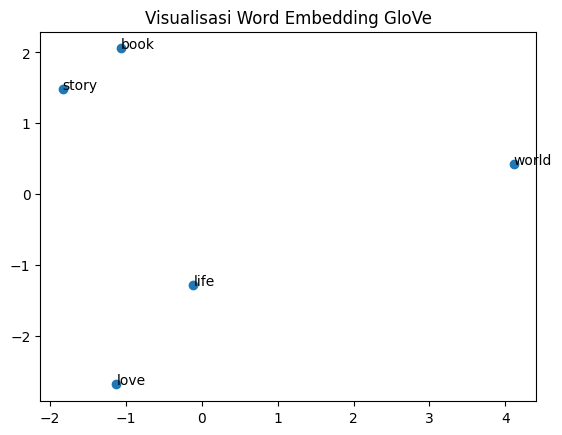

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = ["book", "story", "life", "world", "love"]
vectors = [glove_model[w] for w in words]

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, vectors_2d[i])

plt.title("Visualisasi Word Embedding GloVe")
plt.show()